In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import quandl
import scipy.optimize as sco

plt.style.use('fivethirtyeight')
np.random.seed(777)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
quandl.ApiConfig.api_key='XR1xRaWnVPBK7AMxxbZr'
stocks=['AAPL','AMZN','GOOGL','FB']
data=quandl.get_table('WIKI/PRICES',ticker=stocks,qopts={'columns':['date','ticker','adj_close']},date={'gte':'2016-1-1','lte':'2017-12-31'},paginate=True)
data.head()

,date,ticker,adj_close
None,,,
0,2017-12-29,GOOGL,1053.40
1,2017-12-28,GOOGL,1055.95
2,2017-12-27,GOOGL,1060.20
3,2017-12-26,GOOGL,1065.85
4,2017-12-22,GOOGL,1068.86


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2006 entries, 0 to 2005
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   date       2006 non-null   datetime64[s]
 1   ticker     2006 non-null   str          
 2   adj_close  2006 non-null   float64      
dtypes: datetime64[s](1), float64(1), str(1)
memory usage: 47.1 KB


In [8]:
df=data.set_index('date')
df.tail()

,ticker,adj_close
date,,
2016-01-08,AAPL,93.677776
2016-01-07,AAPL,93.185040
2016-01-06,AAPL,97.291172
2016-01-05,AAPL,99.233131
2016-01-04,AAPL,101.783763


In [10]:
table=df.pivot(columns='ticker')
table.head()

adj_close                        
ticker            AAPL    AMZN      FB   GOOGL
date                                          
2016-01-04  101.783763  636.99  102.22  759.44
2016-01-05   99.233131  633.79  102.73  761.53
2016-01-06   97.291172  632.65  102.97  759.33
2016-01-07   93.185040  607.94   97.92  741.00
2016-01-08   93.677776  607.05   97.33  730.91

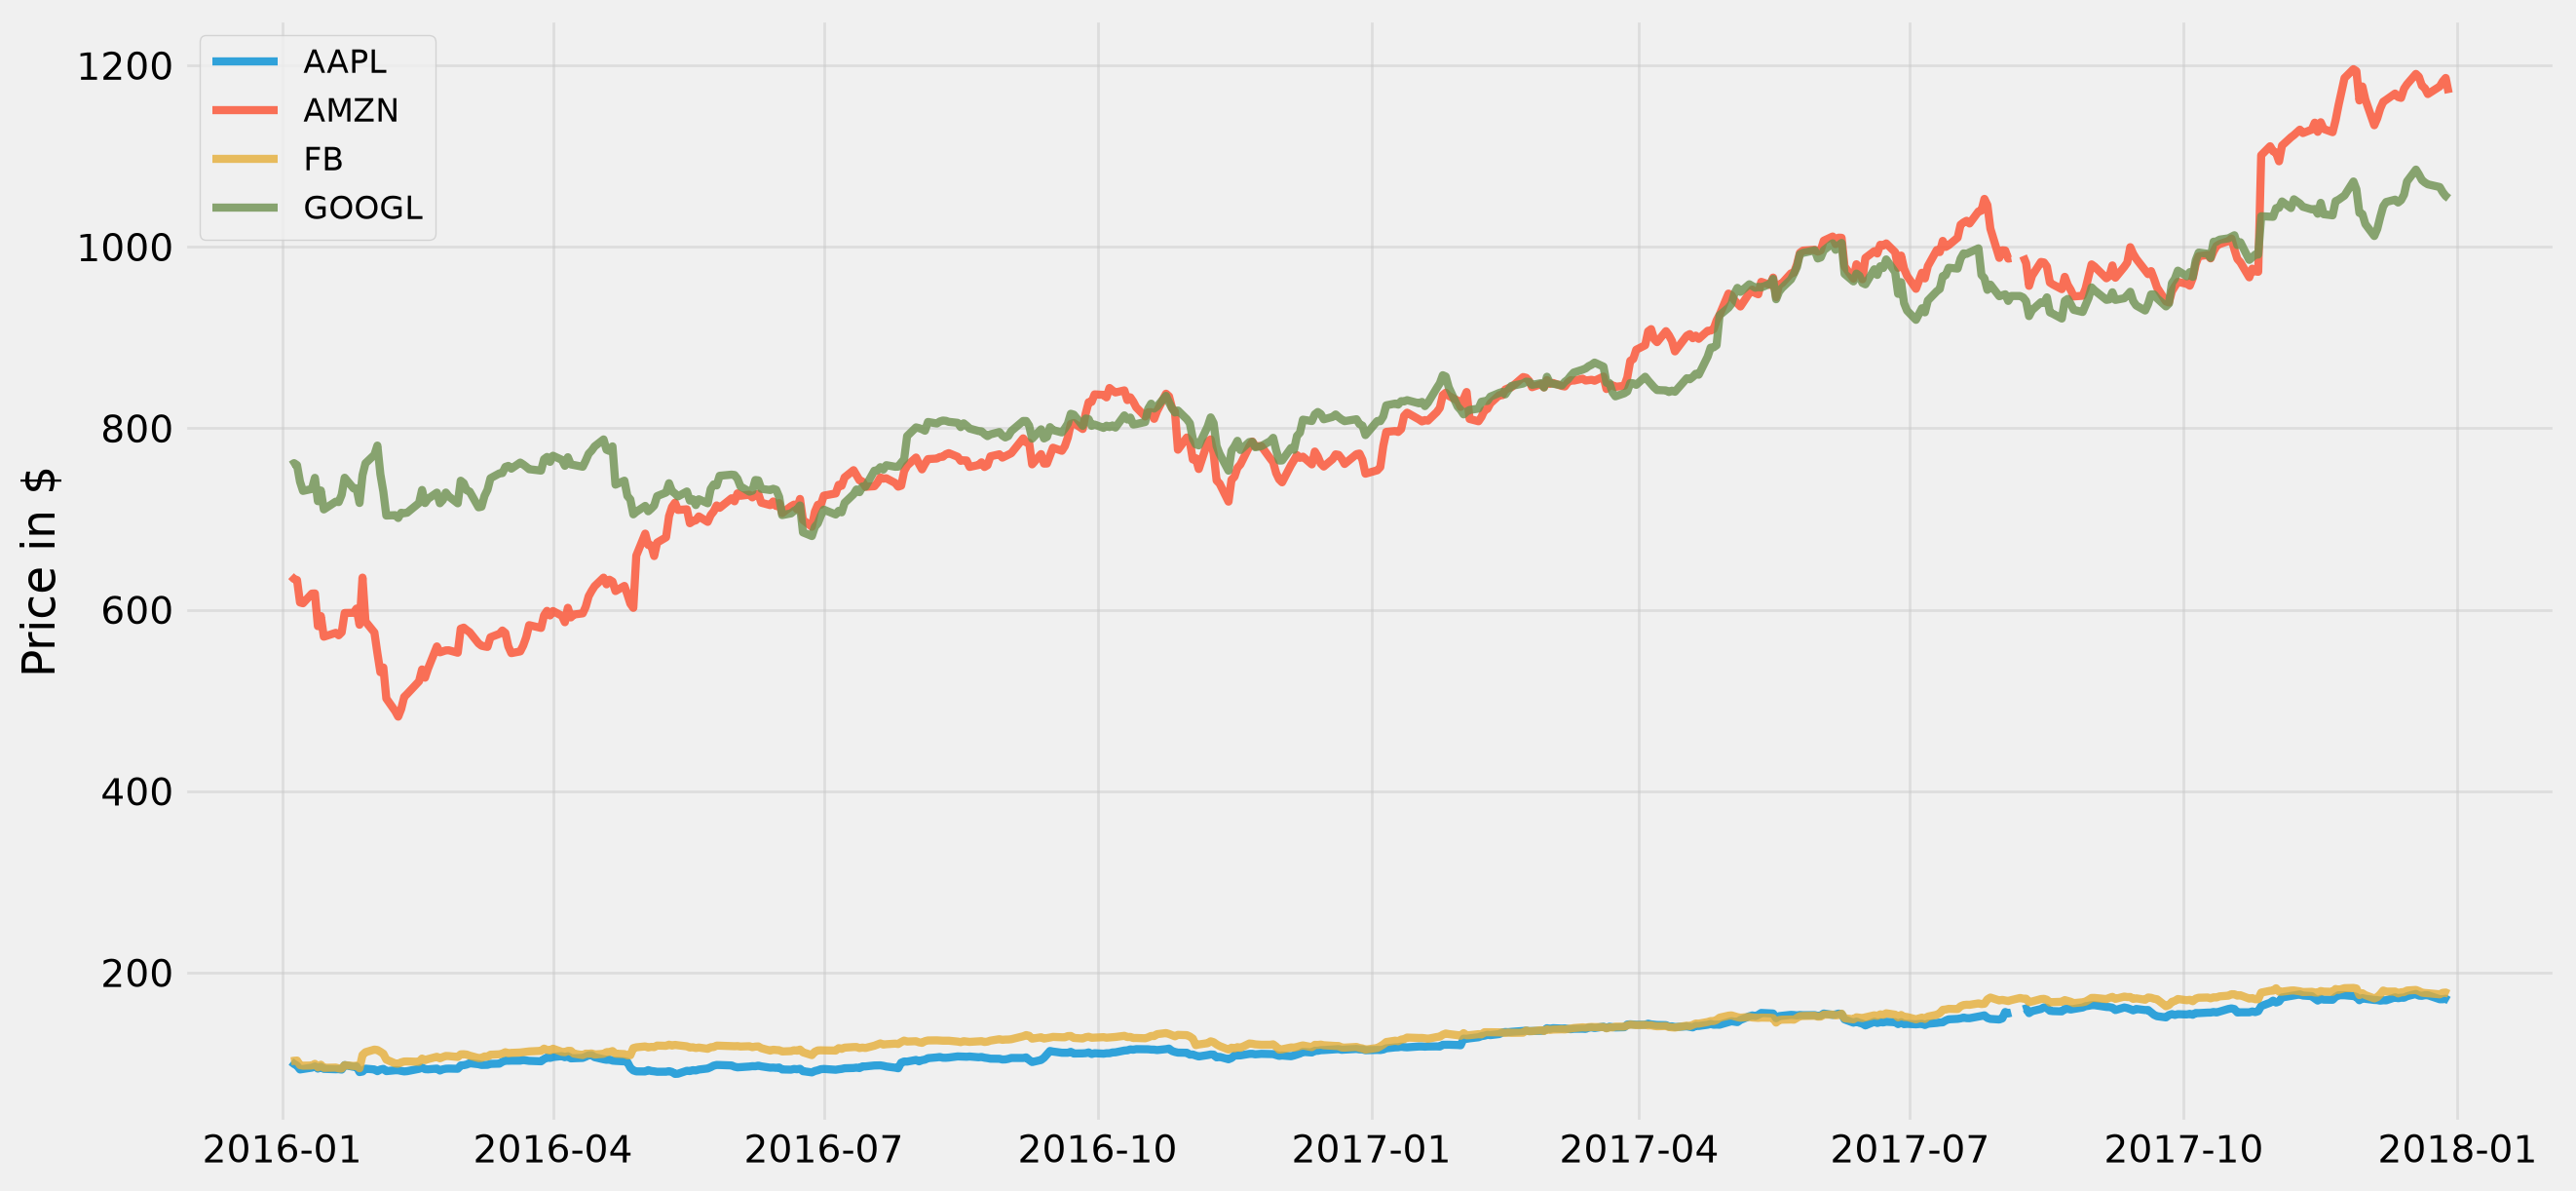

In [16]:
plt.figure(figsize = (14,7))
for c in table.columns.values:
    plt.plot(table.index,table[c],lw=3,alpha=0.8,label=c[1])
plt.legend(loc='upper left',fontsize=12,labelcolor='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.ylabel('Price in $',color='black')
plt.show()

Text(0, 0.5, 'daily returns')

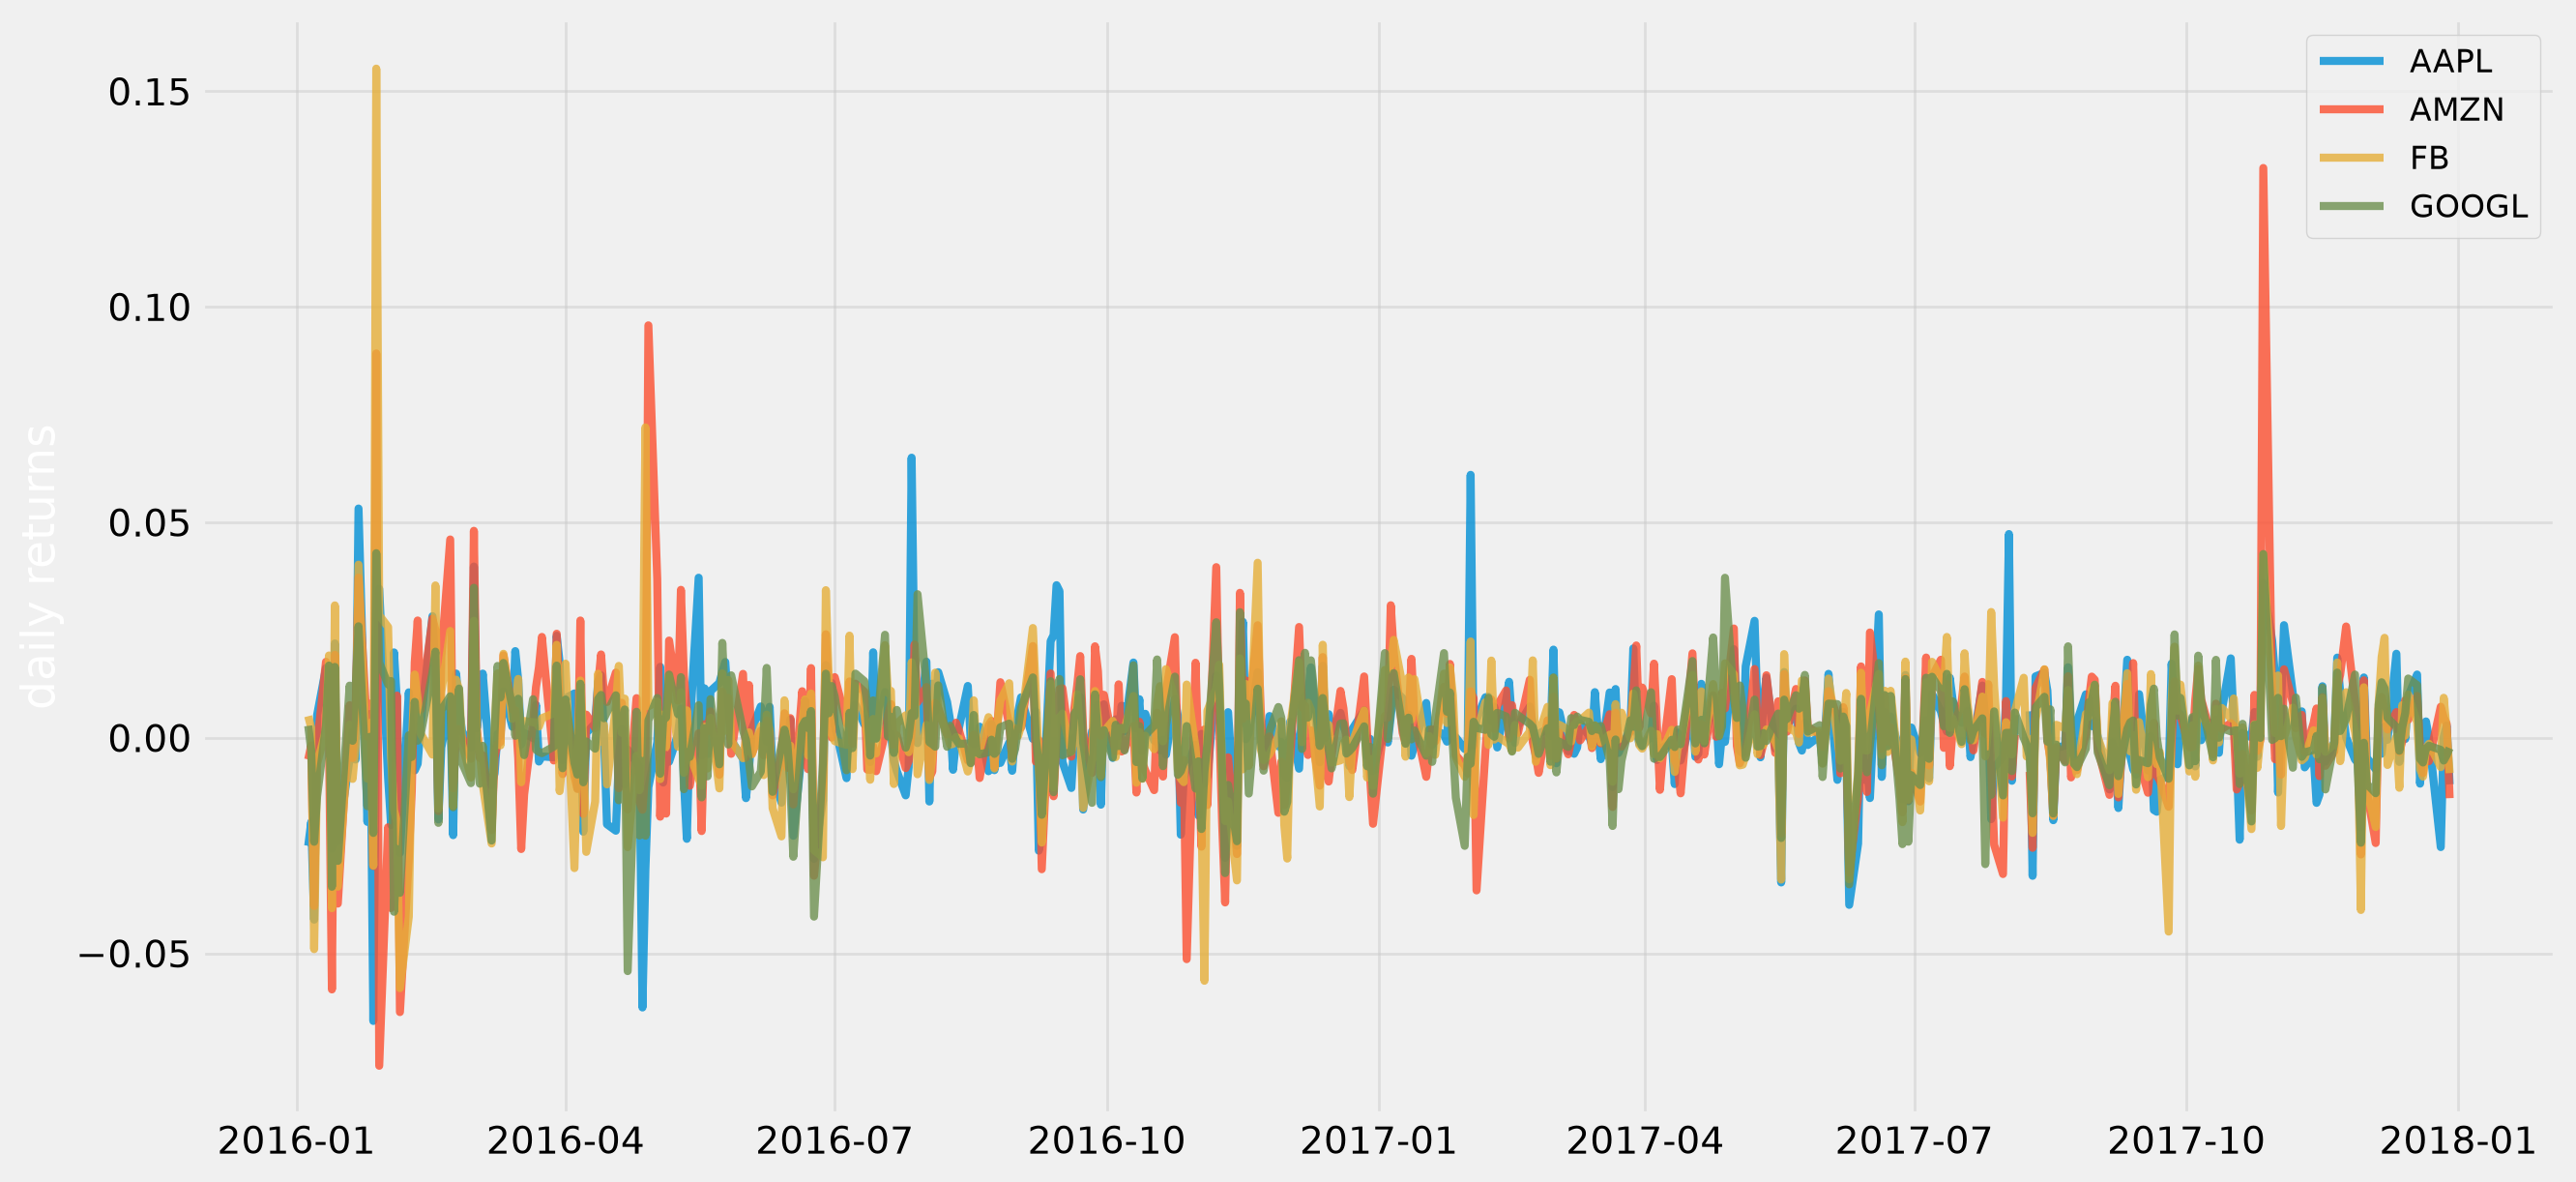

In [19]:
returns=table.pct_change()

plt.figure(figsize=(14, 7))
for c in returns.columns.values:
    plt.plot(returns.index, returns[c], lw=3, alpha=0.8,label=c[1])
plt.legend(loc='upper right', fontsize=12,labelcolor='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.ylabel('daily returns')

In [20]:
def portfolio_annualised_performance(weights,mean_returns,cov_matrix):
    returns=np.sum(mean_returns*weights)*252
    std=np.sqrt(np.dot(weights.T,np.dot(cov_matrix,weights)))*np.sqrt(252)
    return std,returns

In [24]:
def random_portfolios(num_portfolios,mean_returns,cov_matrix,risk_free_rate):
    results=np.zeros((3,num_portfolios))
    weights_records=[]
    for i in range(num_portfolios):
        weights=np.random.random(4)
        weights/=np.sum(weights)
        weights_records.append(weights)
        portfolio_std_dev,portfolio_return=portfolio_annualised_performance(weights,mean_returns,cov_matrix)
        results[0,i]=portfolio_std_dev
        results[1,i]=portfolio_return
        results[2,i]=(portfolio_return-risk_free_rate)/portfolio_std_dev
    return results,weights_records

In [22]:
mean_returns=returns.mean()
cov_matrix=returns.cov()
num_portfolios=25000
risk_free_rate=0.0178

In [27]:
def display_simulated_ef_with_random(mean_returns, cov_matrix, num_portfolios, risk_free_rate):
    results, weights = random_portfolios(num_portfolios,mean_returns, cov_matrix, risk_free_rate)

    max_sharpe_idx = np.argmax(results[2])
    sdp, rp = results[0,max_sharpe_idx], results[1,max_sharpe_idx]
    max_sharpe_allocation = pd.DataFrame(weights[max_sharpe_idx],index=table.columns,columns=['allocation'])
    max_sharpe_allocation.allocation = [round(i*100,2)for i in max_sharpe_allocation.allocation]
    max_sharpe_allocation = max_sharpe_allocation.T

    min_vol_idx = np.argmin(results[0])
    sdp_min, rp_min = results[0,min_vol_idx], results[1,min_vol_idx]
    min_vol_allocation = pd.DataFrame(weights[min_vol_idx],index=table.columns,columns=['allocation'])
    min_vol_allocation.allocation = [round(i*100,2)for i in min_vol_allocation.allocation]
    min_vol_allocation = min_vol_allocation.T

    print ("-"*80)
    print ("Maximum Sharpe Ratio Portfolio Allocation\n")
    print ("Annualised Return:", round(rp,2))
    print ("Annualised Volatility:", round(sdp,2))
    print ("\n")
    print (max_sharpe_allocation)
    print ("-"*80)
    print ("Minimum Volatility Portfolio Allocation\n")
    print ("Annualised Return:", round(rp_min,2))
    print ("Annualised Volatility:", round(sdp_min,2))
    print ("\n")
    print (min_vol_allocation)

    plt.figure(figsize=(10, 7))
    plt.scatter(results[0,:],results[1,:],c=results[2,:],cmap='YlGnBu', marker='o', s=10, alpha=0.3)
    plt.colorbar()
    plt.scatter(sdp,rp,marker='*',color='r',s=500, label='Maximum Sharpe ratio')
    plt.scatter(sdp_min,rp_min,marker='*',color='g',s=500, label='Minimum volatility')
    plt.title('Simulated Portfolio Optimization based on Efficient Frontier',color='black')
    plt.xlabel('annualised volatility',color='black')
    plt.ylabel('annualised returns',color='black')
    plt.xticks(color='black')
    plt.yticks(color='black')
    plt.legend(labelspacing=0.8,labelcolor='black')

--------------------------------------------------------------------------------
Maximum Sharpe Ratio Portfolio Allocation

Annualised Return: 0.3
Annualised Volatility: 0.18


           adj_close                    
ticker          AAPL   AMZN     FB GOOGL
allocation     42.85  30.12  26.86  0.17
--------------------------------------------------------------------------------
Minimum Volatility Portfolio Allocation

Annualised Return: 0.22
Annualised Volatility: 0.16


           adj_close                   
ticker          AAPL  AMZN    FB  GOOGL
allocation     33.61  1.34  8.02  57.02


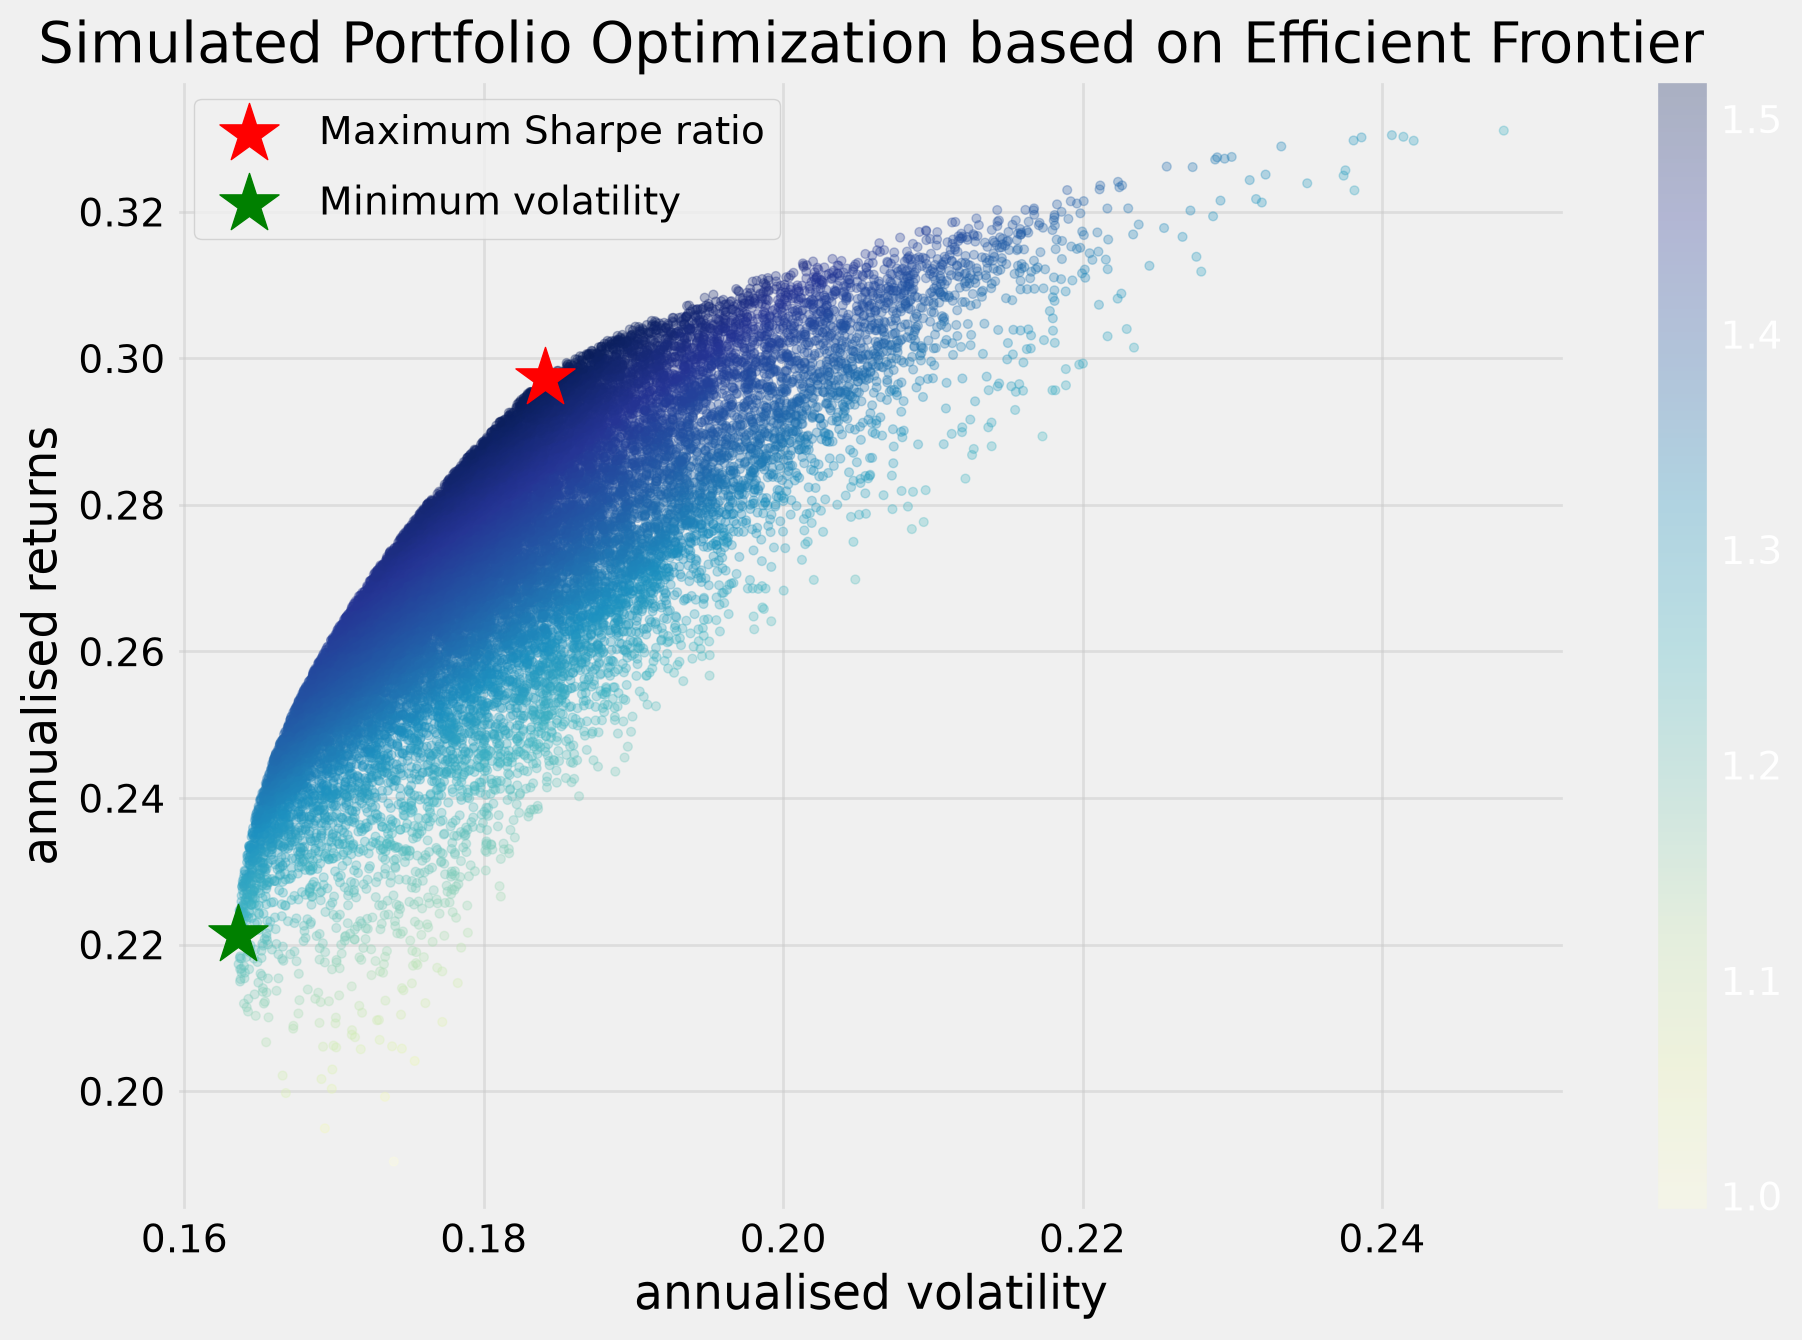

In [28]:
display_simulated_ef_with_random(mean_returns, cov_matrix, num_portfolios, risk_free_rate)

In [29]:
def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_var, p_ret = portfolio_annualised_performance(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_var

def max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix, risk_free_rate)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bound = (0.0,1.0)
    bounds = tuple(bound for asset in range(num_assets))
    result = sco.minimize(neg_sharpe_ratio, num_assets*[1./num_assets,], args=args,
                        method='SLSQP', bounds=bounds, constraints=constraints)
    return result

In [30]:
def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_annualised_performance(weights, mean_returns, cov_matrix)[0]

def min_variance(mean_returns, cov_matrix):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bound = (0.0,1.0)
    bounds = tuple(bound for asset in range(num_assets))

    result = sco.minimize(portfolio_volatility, num_assets*[1./num_assets,], args=args,
                        method='SLSQP', bounds=bounds, constraints=constraints)

    return result

In [31]:
def efficient_return(mean_returns, cov_matrix, target):
    num_assets = len(mean_returns)
    args = (mean_returns, cov_matrix)

    def portfolio_return(weights):
        return portfolio_annualised_performance(weights, mean_returns, cov_matrix)[1]

    constraints = ({'type': 'eq', 'fun': lambda x: portfolio_return(x) - target},
                   {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0,1) for asset in range(num_assets))
    result = sco.minimize(portfolio_volatility, num_assets*[1./num_assets,], args=args, method='SLSQP', bounds=bounds, constraints=constraints)
    return result


def efficient_frontier(mean_returns, cov_matrix, returns_range):
    efficients = []
    for ret in returns_range:
        efficients.append(efficient_return(mean_returns, cov_matrix, ret))
    return efficients

In [35]:
def display_calculated_ef_with_random(mean_returns, cov_matrix, num_portfolios, risk_free_rate):
    results, _ = random_portfolios(num_portfolios,mean_returns, cov_matrix, risk_free_rate)

    max_sharpe = max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate)
    sdp, rp = portfolio_annualised_performance(max_sharpe['x'], mean_returns, cov_matrix)
    max_sharpe_allocation = pd.DataFrame(max_sharpe.x,index=table.columns,columns=['allocation'])
    max_sharpe_allocation.allocation = [round(i*100,2)for i in max_sharpe_allocation.allocation]
    max_sharpe_allocation = max_sharpe_allocation.T
    max_sharpe_allocation

    min_vol = min_variance(mean_returns, cov_matrix)
    sdp_min, rp_min = portfolio_annualised_performance(min_vol['x'], mean_returns, cov_matrix)
    min_vol_allocation = pd.DataFrame(min_vol.x,index=table.columns,columns=['allocation'])
    min_vol_allocation.allocation = [round(i*100,2)for i in min_vol_allocation.allocation]
    min_vol_allocation = min_vol_allocation.T

    print ("-"*80)
    print ("Maximum Sharpe Ratio Portfolio Allocation\n")
    print ("Annualised Return:", round(rp,2))
    print ("Annualised Volatility:", round(sdp,2))
    print ("\n")
    print (max_sharpe_allocation)
    print ("-"*80)
    print ("Minimum Volatility Portfolio Allocation\n")
    print ("Annualised Return:", round(rp_min,2))
    print ("Annualised Volatility:", round(sdp_min,2))
    print ("\n")
    print (min_vol_allocation)

    plt.figure(figsize=(10, 7))
    plt.scatter(results[0,:],results[1,:],c=results[2,:],cmap='YlGnBu', marker='o', s=10, alpha=0.3)
    plt.colorbar()
    plt.scatter(sdp,rp,marker='*',color='r',s=500, label='Maximum Sharpe ratio')
    plt.scatter(sdp_min,rp_min,marker='*',color='g',s=500, label='Minimum volatility')

    target = np.linspace(rp_min, 0.32, 50)
    efficient_portfolios = efficient_frontier(mean_returns, cov_matrix, target)
    plt.plot([p['fun'] for p in efficient_portfolios], target, linestyle='-.', color='black', label='efficient frontier')
    plt.title('Calculated Portfolio Optimization based on Efficient Frontier',color='black')
    plt.xlabel('annualised volatility',color='black')
    plt.ylabel('annualised returns',color='black')
    plt.xticks(color='black')
    plt.yticks(color='black')
    plt.legend(labelspacing=0.8,labelcolor='black')

--------------------------------------------------------------------------------
Maximum Sharpe Ratio Portfolio Allocation

Annualised Return: 0.3
Annualised Volatility: 0.18


           adj_close                    
ticker          AAPL   AMZN     FB GOOGL
allocation     41.95  30.43  27.62   0.0
--------------------------------------------------------------------------------
Minimum Volatility Portfolio Allocation

Annualised Return: 0.22
Annualised Volatility: 0.16


           adj_close                   
ticker          AAPL  AMZN    FB  GOOGL
allocation     34.15  0.48  6.85  58.52


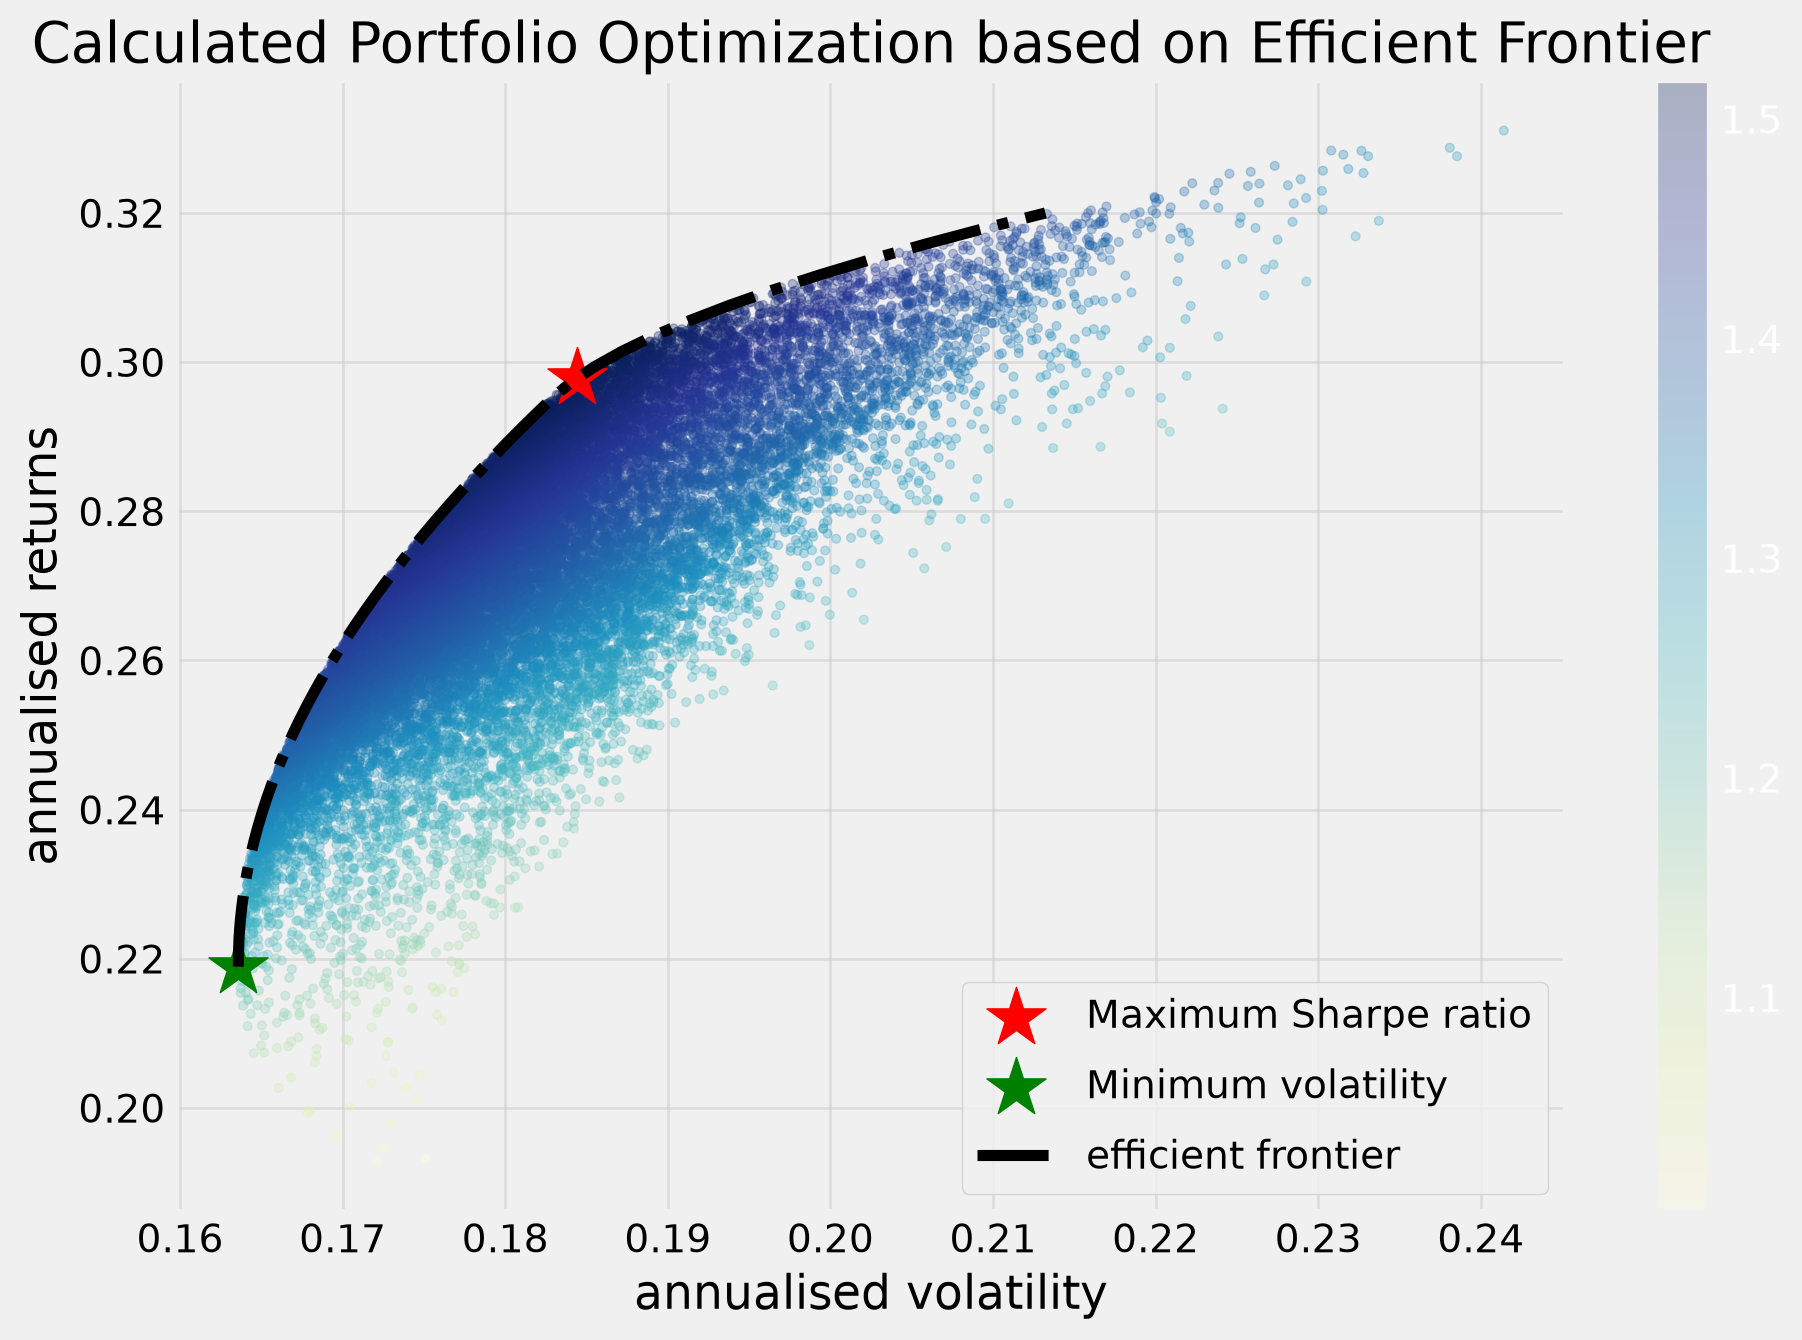

In [36]:
display_calculated_ef_with_random(mean_returns, cov_matrix, num_portfolios, risk_free_rate)

In [50]:
def display_ef_with_selected(mean_returns, cov_matrix, risk_free_rate):
    max_sharpe = max_sharpe_ratio(mean_returns, cov_matrix, risk_free_rate)
    sdp, rp = portfolio_annualised_performance(max_sharpe['x'], mean_returns, cov_matrix)
    max_sharpe_allocation = pd.DataFrame(max_sharpe.x,index=table.columns,columns=['allocation'])
    max_sharpe_allocation.allocation = [round(i*100,2)for i in max_sharpe_allocation.allocation]
    max_sharpe_allocation = max_sharpe_allocation.T
    max_sharpe_allocation

    min_vol = min_variance(mean_returns, cov_matrix)
    sdp_min, rp_min = portfolio_annualised_performance(min_vol['x'], mean_returns, cov_matrix)
    min_vol_allocation = pd.DataFrame(min_vol.x,index=table.columns,columns=['allocation'])
    min_vol_allocation.allocation = [round(i*100,2)for i in min_vol_allocation.allocation]
    min_vol_allocation = min_vol_allocation.T

    an_vol = returns.std() * np.sqrt(252)
    an_rt = mean_returns * 252

    print ("-"*80)
    print ("Maximum Sharpe Ratio Portfolio Allocation\n")
    print ("Annualised Return:", round(rp,2))
    print ("Annualised Volatility:", round(sdp,2))
    print ("\n")
    print (max_sharpe_allocation)
    print ("-"*80)
    print ("Minimum Volatility Portfolio Allocation\n")
    print ("Annualised Return:", round(rp_min,2))
    print ("Annualised Volatility:", round(sdp_min,2))
    print ("\n")
    print (min_vol_allocation)
    print ("-"*80)
    print ("Individual Stock Returns and Volatility\n")
    for i, txt in enumerate(table.columns):
        print (txt,":","annuaised return",round(an_rt.iloc[i],2),", annualised volatility:",round(an_vol.iloc[i],2))
    print ("-"*80)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(an_vol,an_rt,marker='o',s=200)

    for i, txt in enumerate(table.columns.get_level_values('ticker')):
        ax.annotate(txt, (an_vol.iloc[i],an_rt.iloc[i]), xytext=(10,0), textcoords='offset points',color='black')
    ax.scatter(sdp,rp,marker='*',color='r',s=500, label='Maximum Sharpe ratio')
    ax.scatter(sdp_min,rp_min,marker='*',color='g',s=500, label='Minimum volatility')

    target = np.linspace(rp_min, 0.34, 50)
    efficient_portfolios = efficient_frontier(mean_returns, cov_matrix, target)
    ax.plot([p['fun'] for p in efficient_portfolios], target, linestyle='-.', color='black', label='efficient frontier')
    ax.set_title('Portfolio Optimization with Individual Stocks',color='black')
    ax.set_xlabel('annualised volatility',color='black')
    ax.set_ylabel('annualised returns',color='black')
    ax.tick_params(axis='x', colors='black')
    ax.tick_params(axis='y', colors='black')
    ax.legend(labelspacing=0.8,labelcolor='black')

--------------------------------------------------------------------------------
Maximum Sharpe Ratio Portfolio Allocation

Annualised Return: 0.3
Annualised Volatility: 0.18


           adj_close                    
ticker          AAPL   AMZN     FB GOOGL
allocation     41.95  30.43  27.62   0.0
--------------------------------------------------------------------------------
Minimum Volatility Portfolio Allocation

Annualised Return: 0.22
Annualised Volatility: 0.16


           adj_close                   
ticker          AAPL  AMZN    FB  GOOGL
allocation     34.15  0.48  6.85  58.52
--------------------------------------------------------------------------------
Individual Stock Returns and Volatility

('adj_close', 'AAPL') : annuaised return 0.27 , annualised volatility: 0.21
('adj_close', 'AMZN') : annuaised return 0.34 , annualised volatility: 0.25
('adj_close', 'FB') : annuaised return 0.3 , annualised volatility: 0.23
('adj_close', 'GOOGL') : annuaised return 0.18 , annualis

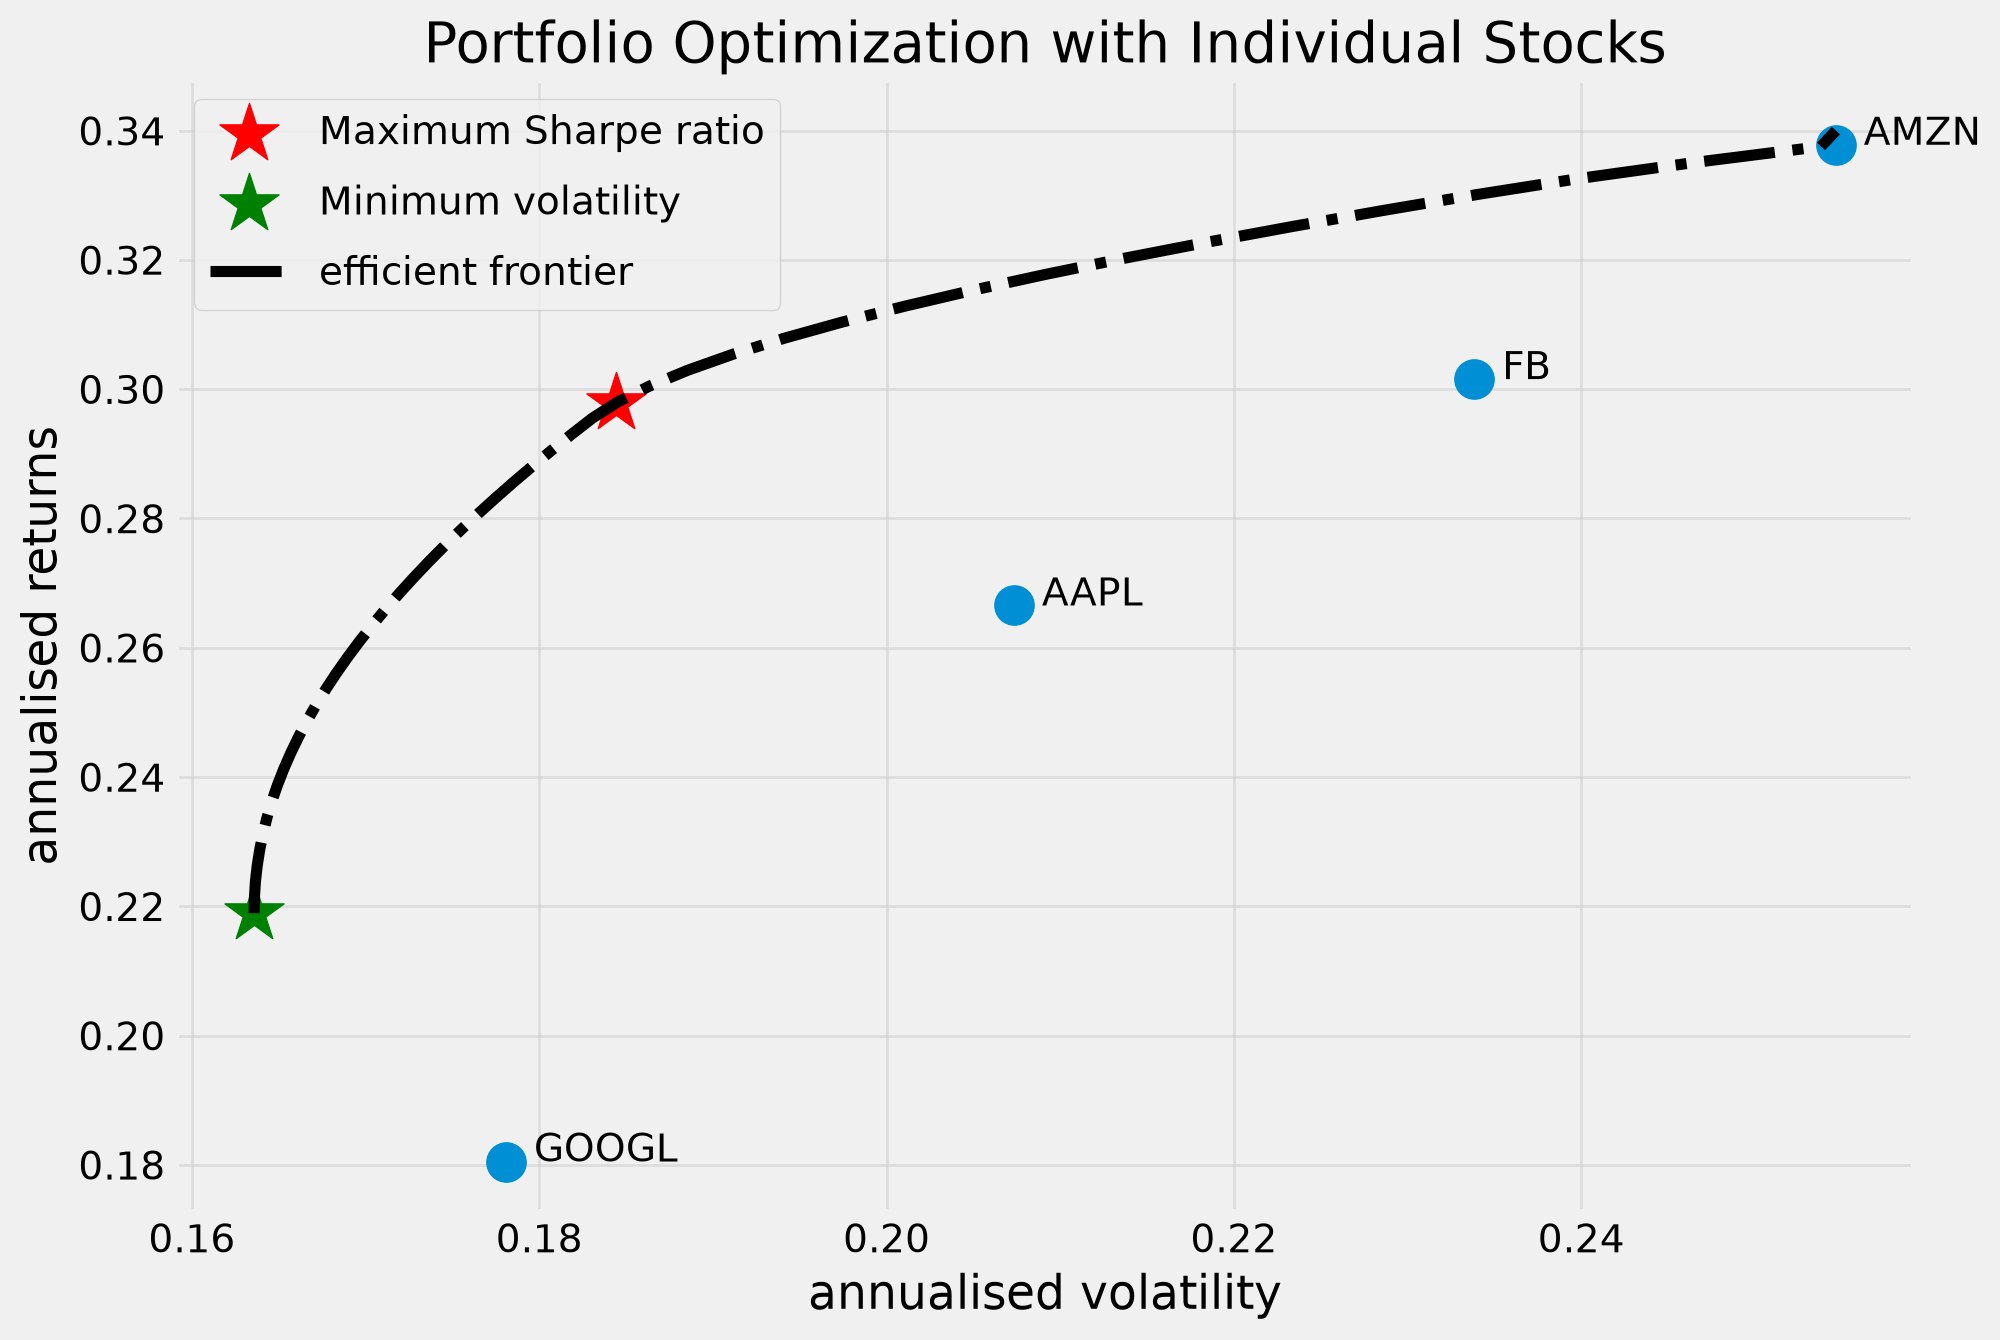

In [51]:
display_ef_with_selected(mean_returns, cov_matrix, risk_free_rate)